# Modelo preliminar y línea base

Este cuaderno entrena una regresión logística sencilla y la evalúa con AUC. La validación usa las ofertas más recientes y mantiene el orden de `offerdate`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT_DIR = Path.cwd().resolve()
if not (ROOT_DIR / 'src').exists():
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR / 'src'))

from config import FIGURES_DIR, MODELS_DIR, TABLES_DIR
from modelo import (
    COLUMNAS_LINEA_BASE,
    crear_pipeline_linea_base,
    dividir_temporalmente,
    evaluar_auc,
    guardar_modelo,
    tabla_coeficientes,
)
from preprocesamiento import cargar_dataset_modelo

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## Carga y separación temporal

El último bloque de fechas se reserva para validación. Un mismo día nunca aparece en los dos conjuntos.

In [2]:
dataset = cargar_dataset_modelo()
division = dividir_temporalmente(dataset, proporcion_validacion=0.20)
train = division.entrenamiento
validacion = division.validacion

resumen_split = pd.DataFrame([
    {
        'conjunto': 'entrenamiento',
        'filas': len(train),
        'fecha_inicial': train['offerdate'].min().date(),
        'fecha_final': train['offerdate'].max().date(),
        'tasa_recompra': train['repeater'].mean(),
    },
    {
        'conjunto': 'validacion',
        'filas': len(validacion),
        'fecha_inicial': validacion['offerdate'].min().date(),
        'fecha_final': validacion['offerdate'].max().date(),
        'tasa_recompra': validacion['repeater'].mean(),
    },
])
resumen_split.to_csv(TABLES_DIR / '05_split_temporal.csv', index=False)
resumen_split

,conjunto,filas,fecha_inicial,fecha_final,tasa_recompra
0,entrenamiento,124558,2013-03-01,2013-04-23,0.246391
1,validacion,35499,2013-04-24,2013-04-30,0.359109


## Entrenamiento

La línea base usa el valor de la oferta y variables sencillas de recencia, frecuencia y monto. Se excluyen `id`, `offer` y `repeattrips`.

In [3]:
linea_base = crear_pipeline_linea_base()
linea_base.fit(train, train['repeater'].astype(int))
evaluacion_base = evaluar_auc(linea_base, validacion)

guardar_modelo(linea_base, MODELS_DIR / '05_regresion_logistica_linea_base.joblib')
metricas_base = pd.DataFrame([{
    'modelo': 'regresion_logistica_linea_base',
    'auc_validacion_temporal': evaluacion_base['auc'],
    'fecha_corte': division.fecha_corte.date(),
    'n_entrenamiento': len(train),
    'n_validacion': len(validacion),
}])
metricas_base.to_csv(TABLES_DIR / '05_metricas_linea_base.csv', index=False)
metricas_base

,modelo,auc_validacion_temporal,fecha_corte,n_entrenamiento,n_validacion
0,regresion_logistica_linea_base,0.561354,2013-04-24,124558,35499


## Curva ROC y coeficientes

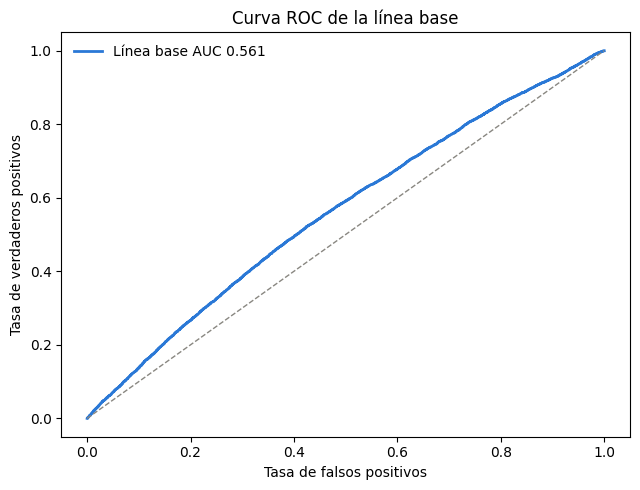

,variable,coeficiente,magnitud
0,gasto_total,1.832226,1.832226
1,ticket_promedio,0.440037,0.440037
2,offervalue,-0.280999,0.280999
3,dias_ultima_compra,-0.081614,0.081614
4,antiguedad_dias,-0.077984,0.077984
5,n_visitas,0.067757,0.067757
6,quantity,0.000000,0.000000


In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(evaluacion_base['fpr'], evaluacion_base['tpr'], color='#2a78d6', linewidth=2, label=f"Línea base AUC {evaluacion_base['auc']:.3f}")
ax.plot([0, 1], [0, 1], color='#898781', linestyle='--', linewidth=1)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC de la línea base')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_curva_roc_linea_base.png', dpi=150, bbox_inches='tight')
plt.show()

coeficientes_base = tabla_coeficientes(linea_base)
coeficientes_base.to_csv(TABLES_DIR / '05_coeficientes_linea_base.csv', index=False)
coeficientes_base

## Resultado

El AUC obtenido es una referencia para medir la mejora del siguiente cuaderno. La diferencia de tasa de recompra entre los periodos confirma que la validación temporal es más exigente que una partición aleatoria.